# NB to check the WFs from Run 15589

In [47]:
import warnings

import tables as tb
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

### Miremos una wf

In [48]:
run_n = 15589
file_n = '0311'

In [49]:
wf_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_runs/{run_n}/selected_wfs/selected_rwf_{run_n}_{file_n}.h5'.format(run_n = run_n, file_n = file_n)

In [50]:
with tb.open_file(wf_path, 'r') as h5in:
    print(h5in)

/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_runs/15589/selected_wfs/selected_rwf_15589_0311.h5 (File) ''
Last modif.: '2025-07-28T10:58:00+00:00'
Object Tree: 
/ (RootGroup) ''
/evtmap (Table(100,)shuffle, zlib(4)) 'event mapping'
/RD (Group) ''
/RD/pmtrwf (EArray(100, 60, 116000)shuffle, zlib(4)) ''
/RD/sipmrwf (EArray(100, 3584, 2900)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/events (Table(100,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(100,)shuffle, zlib(4)) 'run info table'



In [51]:
pd.read_hdf(wf_path, 'evtmap')

,evt_number,file_no,ldc,filename
0,3830333,5371,3,run_15589_5371_ldc3_trg2.waveforms
1,3830620,5371,3,run_15589_5371_ldc3_trg2.waveforms
2,3830921,5371,3,run_15589_5371_ldc3_trg2.waveforms
3,3830956,5372,3,run_15589_5372_ldc3_trg2.waveforms
4,3831173,5372,3,run_15589_5372_ldc3_trg2.waveforms
...,...,...,...,...
95,20514,27,4,run_15589_0027_ldc4_trg2.waveforms
96,20584,27,4,run_15589_0027_ldc4_trg2.waveforms
97,20745,27,4,run_15589_0027_ldc4_trg2.waveforms
98,21935,29,4,run_15589_0029_ldc4_trg2.waveforms


In [52]:
from invisible_cities.cities.components import deconv_pmt
# Parameters for deconvolution
DETECTOR_DB = 'next100'  # As requested, for NEXT100 database
RUN_NUMBER = 15589     # The run number for this analysis
BASELINE_SAMPLES = 4000  # Number of initial samples for baseline/deconvolution


In [53]:
def get_waveform_for_event(filepath, event_number):
    """
    Reads the full PMT RWF for a specific event from a waveform file.
    """
    with tb.open_file(filepath, 'r') as h5file:
        try:
            events_table = h5file.root.Run.events
            pmtrwf_node = h5file.root.RD.pmtrwf
        except tb.NoSuchNodeError as e:
            warnings.warn(f"Required table/group not found in {filepath}: {e}")
            return None

        # Find the index corresponding to the event number
        event_indices = np.where(events_table.col('evt_number') == event_number)[0]
        if len(event_indices) == 0:
            warnings.warn(f"Event {event_number} not found in event map of {filepath}")
            return None
        
        event_index = event_indices[0]
        
        # Read the specific event waveform
        waveform = pmtrwf_node[event_index, :, :]
        return waveform

In [136]:
dat_id = 10084 #13780 #1047

In [137]:
raw_waveform_data = get_waveform_for_event(wf_path, dat_id)
deconvolver = deconv_pmt(DETECTOR_DB, RUN_NUMBER, BASELINE_SAMPLES)
deconvolved_pmts = deconvolver(raw_waveform_data)

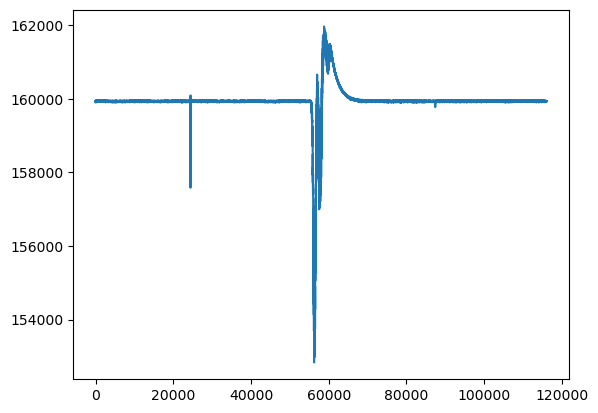

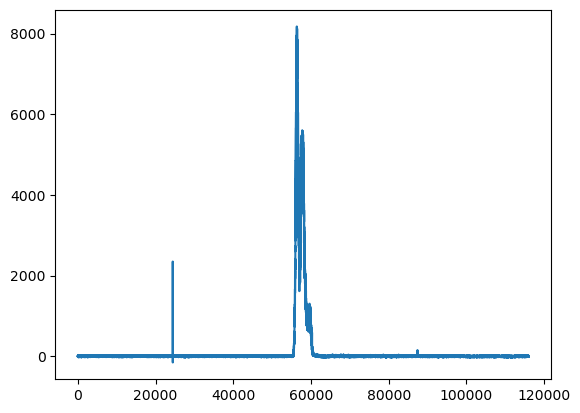

In [138]:
plt.plot(raw_waveform_data.sum(axis = 0))
plt.show()
plt.plot(deconvolved_pmts.sum(axis = 0))

Con esto solo tengo la WF, no los PMAPS, entonces no puedo ver qué es lo que selecciona. Puedo o copiar esos PMAPS, o correr irene y así tb modificar el config como plazca.

## Run Irene

In [139]:
import warnings
import tables as tb
import numpy as np

from invisible_cities.core.system_of_units import *
from invisible_cities.types.symbols import SiPMThreshold, WfType

from invisible_cities.cities.components import get_run_number, get_pmt_wfs, get_sipm_wfs, get_trigger_info
from invisible_cities.cities.components import deconv_pmt, calibrate_pmts, zero_suppress_wfs, get_actual_sipm_thr
from invisible_cities.cities.components import check_nonempty_indices, calibrate_sipms, build_pmap, check_empty_pmap


In [140]:
def get_dct_wf(filepath, event_number, wf_type = WfType.rwf):
    """
    Retrieves a dictionary with full event info (PMT/SIPM waveforms, event info, trigger info)
    for a specific event number from a given file, using direct indexing.
    """
    with tb.open_file(filepath, 'r') as h5file:
        try:
            events_table = h5file.root.Run.events
            pmt_wfs      = get_pmt_wfs(h5file, wf_type)
            sipm_wfs     = get_sipm_wfs(h5file, wf_type)
            trg_type, trg_chann = get_trigger_info(h5file)
            run_number   = get_run_number(h5file)
        except tb.NoSuchNodeError as e:
            warnings.warn(f"Missing node in file {filepath}: {e}")
            return None

        # Find the row index corresponding to the event number
        event_indices = np.where(events_table.col('evt_number') == event_number)[0]
        if len(event_indices) == 0:
            warnings.warn(f"Event {event_number} not found in {filepath}")
            return None

        i = event_indices[0]

        # Extract event info
        timestamp = events_table[i]['timestamp']
        pmt       = pmt_wfs[i]
        sipm      = sipm_wfs[i]
        trtyp     = next(trg_type) if trg_type is not None else None
        trchn     = next(trg_chann) if trg_chann is not None else None

        return dict(
            pmt=pmt,
            sipm=sipm,
            run_number=run_number,
            event_number=event_number,
            timestamp=timestamp,
            trigger_type=trtyp,
            trigger_channels=trchn
        )

In [141]:
files_in    = "/jobs/498a72f3-9e59-4d48-8926-d9e793691bb0/run_15281_0000_ldc1_trg2.waveforms.h5"
file_out    = "/jobs/498a72f3-9e59-4d48-8926-d9e793691bb0/run_15281_0000_ldc1_trg2.v2.3.1.20250429.HE.irene.h5"
compression = "ZLIB4"
run_number  = 15589
detector_db = "next100"
print_mod   = 10000
event_range = all


# max number of events to run
event_range = all

n_baseline     = 112000 # 62400 ### this one was the bad one


# Set MAU for calibrated sum
n_maw   = 100
thr_maw =   3 * adc

# Set thresholds for calibrated sum
thr_csum_s1 = 0.1 * pes  ### TO BE CHECKED!!!
thr_csum_s2 = 0.1 * pes  ### TO BE CHECKED!!!

# Set MAU thresholds for SiPM
thr_sipm      = 1.0 * pes
thr_sipm_type = SiPMThreshold.common

# Set parameters to search for S1
s1_tmin       =   0 * mus # 
s1_tmax       =   1380 * mus # 
s1_stride     =   1       # used to be 4 for some reason 
s1_lmin       =   6       # 6 x 25 = 150 ns
s1_lmax       =  40       # 40 x 25 = 1 mus
s1_rebin_stride = 1       # Do not rebin S1 by default

# Set parameters to search for S2
s2_tmin     =      0 * mus  # do not consider full window to speed up 
s2_tmax     =   2800 * mus  # end of the window
s2_stride   =     20        #  40 x 25 = 1   mus
s2_lmin     =    400        # 400 x 25 = 10 mus
s2_lmax     = 1000000        # maximum value of S2 width
s2_rebin_stride = 40        # Rebin by default, 40x25 ns time bins to make one 1us time bin

# Set S2Si parameters
thr_sipm_s2 = 5.0 * pes  # Threshold for the full sipm waveform

pmt_samp_wid  = 25 * ns
sipm_samp_wid =  1 * mus

In [142]:
sipm_thr = get_actual_sipm_thr(thr_sipm_type, thr_sipm, detector_db, run_number)

event = get_dct_wf(wf_path, dat_id)
event['cwf'] = deconv_pmt(detector_db, run_number, n_baseline)(event['pmt'])
event["ccwfs"], event["ccwfs_maw"], event["cwf_sum"], event["cwf_sum_maw"] = calibrate_pmts(detector_db, run_number, n_maw, thr_maw)(event["cwf"])
event["s1_indices"], event["s2_indices"] = zero_suppress_wfs(thr_csum_s1, thr_csum_s2)(event["cwf_sum"], event["cwf_sum_maw"]) #aquí había un output mas pero da error y parece que no se usa

event["indices_pass"] = check_nonempty_indices(event["s1_indices"], event["s2_indices"])
event['sipm'] = calibrate_sipms(detector_db, run_number, sipm_thr)(event['sipm']) #entiendo que lo que hace esta funcion es sobreescribir sobre el mismo item 'sipm', en lugar de tener input/output

event["pmap"] = build_pmap(detector_db, run_number, pmt_samp_wid, sipm_samp_wid,
                                         s1_lmax, s1_lmin, s1_rebin_stride, s1_stride, s1_tmax, s1_tmin,
                                         s2_lmax, s2_lmin, s2_rebin_stride, s2_stride, s2_tmax, s2_tmin, thr_sipm_s2)(event["ccwfs"], event["s1_indices"], event["s2_indices"], event['sipm'])

event['pmaps_pass'] = check_empty_pmap(event["pmap"])

Ahora me falta de PMAP object a DF para poder plotear

In [143]:
def store_peak_df(peak, peak_number, event, pmt_list, pmti_list, si_list):
    for i, t in enumerate(peak.times):
        pmt_list.append({
            'event' : event,
            'peak'  : peak_number,
            'time'  : t,
            'bwidth': peak.bin_widths[i],
            'ene'   : peak.pmts.sum_over_sensors[i]
        })

    for pmt_id in peak.pmts.ids:
        for e in peak.pmts.waveform(pmt_id):
            pmti_list.append({
                'event': event,
                'peak' : peak_number,
                'npmt' : pmt_id,
                'ene'  : e
            })

    if peak.sipms is not None and si_list is not None:
        for sipm_id in peak.sipms.ids:
            for q in peak.sipms.waveform(sipm_id):
                si_list.append({
                    'event': event,
                    'peak' : peak_number,
                    'nsipm': sipm_id,
                    'ene'  : q
                })

def pmap_to_dfs(pmap, event_number):
    s1_rows    = []
    s2_rows    = []
    s2si_rows  = []
    s1pmt_rows = []
    s2pmt_rows = []

    for peak_number, s1 in enumerate(pmap.s1s):
        store_peak_df(s1, peak_number, event_number, s1_rows, s1pmt_rows, None)

    for peak_number, s2 in enumerate(pmap.s2s):
        store_peak_df(s2, peak_number, event_number, s2_rows, s2pmt_rows, s2si_rows)

    return {
        'S1'   : pd.DataFrame(s1_rows),
        'S2'   : pd.DataFrame(s2_rows),
        'S2Si' : pd.DataFrame(s2si_rows),
        'S1Pmt': pd.DataFrame(s1pmt_rows),
        'S2Pmt': pd.DataFrame(s2pmt_rows)
    }


In [144]:
event['pmap_df'] = pmap_to_dfs(event['pmap'], dat_id)

In [145]:
s1, s2, s2sipm, s1pmt, s2pmt = event['pmap_df']['S1'], event['pmap_df']['S2'], event['pmap_df']['S2Si'], event['pmap_df']['S1Pmt'], event['pmap_df']['S2Pmt']

In [146]:
deconvolved_wf_sum = np.sum(event['cwf'], axis=0)
time_axis_us = np.arange(len(deconvolved_wf_sum)) * pmt_samp_wid  / 1000

In [147]:
from invisible_cities.cities.components import peak_classifier
from operator import attrgetter

s1_params = dict(
s1_nmin     =    0,
s1_nmax     =    100,
s1_emin     =   40 * pes,
s1_emax     =  1e9 * pes,
s1_wmin     =  200 * ns,
s1_wmax     =  1e9 * mus,
s1_hmin     =    0 * pes,
s1_hmax     =  1e9 * pes,
s1_ethr     =    0 * pes,
)

s2_params = dict(
s2_nmin     =    1,
s2_nmax     =    1e3,
s2_emin     =    3000 * pes, # Reject fake S2 induced by PMT noise
s2_emax     =  1e9 * pes,
s2_wmin     =  2.0 * mus,
s2_wmax     =  1e9 * mus,
s2_hmin     =    0 * pes,
s2_hmax     =  1e9 * pes,
s2_ethr     =    0 * pes,
s2_nsipmmin =    1,
s2_nsipmmax = 6000, # no cut
)

event['selector_output'] = peak_classifier(**s1_params, **s2_params)(event['pmap'])
s1_selected_peak_num = [i for i, val in enumerate(event['selector_output'].s1_peaks) if val]
s2_selected_peak_num = [i for i, val in enumerate(event['selector_output'].s2_peaks) if val]

s1_selected_peak = s1[np.isin(s1.peak, s1_selected_peak_num)]
s2_selected_peak = s2[np.isin(s2.peak, s2_selected_peak_num)]
s2_sipm_selected_peak = s2sipm[np.isin(s2sipm.peak, s2_selected_peak_num)]

In [148]:
# for peak, df in s2.groupby('peak'):
#     plt.plot(df.time / 1000, df.ene, label = peak)
# plt.legend()

In [149]:
# peak = 7

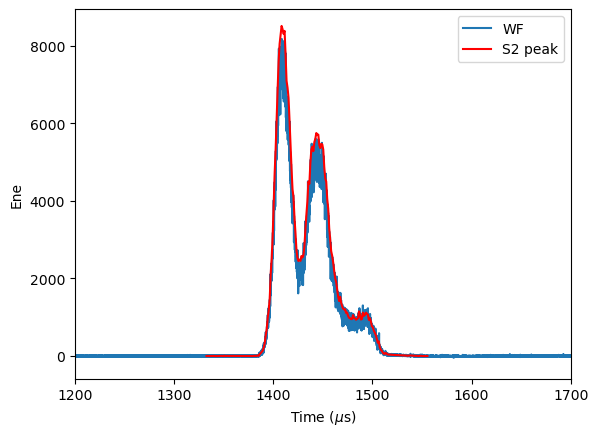

In [151]:
plt.plot(time_axis_us, deconvolved_wf_sum, label = 'WF')
plt.plot(s2_selected_peak.time / 1000, s2_selected_peak.ene, label = 'S2 peak', color = 'r')
# plt.title('PMT CWF')
plt.ylabel('Ene')
plt.xlabel('Time ($\mu$s)')
plt.xlim((1200, 1700))
plt.legend()

In [ ]:
10084